In [ ]:
# # Imports and CPU-only setup

from functools import partial
import os

# --- force JAX to use CPU (and ignore CUDA if present) ---
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import jax
import jax.numpy as jnp
from jax import lax
import jax.tree_util as tree_util

import numpy as onp
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
from numpyro.infer.initialization import init_to_value

import torch
device_torch = torch.device("cpu")
print("Torch using device:", device_torch)

# Configure JAX
jax.config.update("jax_platform_name", "cpu")
print("JAX devices:", jax.devices())


# Set random seed for reproducibility
onp.random.seed(0)
key_global = jax.random.PRNGKey(0)


In [ ]:
# --- Helper Physics Functions ---
def DeltaCal_jnp(x):
    """Calculate grid spacing"""
    dx = jnp.zeros_like(x)
    dx = dx.at[:-1].set(x[1:] - x[:-1])
    dx = dx.at[-1].set(dx[-2])
    return dx

def EnergyCal_jnp(rho, u, P, gamma):
    return P / (gamma - 1.0) + 0.5 * rho * u**2

def ConservCal_jnp(rho, u, E, A):
    """Convert Primitives to Conservative Variables"""
    return jnp.stack([rho * A, rho * u * A, E * A], axis=0)

def PrimCal_jnp(Q, A):
    """Convert Conservative to Primitive Variables"""
    rho = Q[0] / A
    u   = Q[1] / Q[0]
    E   = Q[2] / A
    return rho, u, E

def PressureCal_jnp(rho, u, E, gamma):
    return (gamma - 1.0) * (E - 0.5 * rho * u**2)

# --- Flux Splitting (Steger-Warming style) ---
def FluxSplitCal_vec_jnp(rho, u, P, E, A, dAdx, gamma):
    N = u.size
    zeros = jnp.zeros(N)
    c = jnp.sqrt(jnp.abs(gamma * P / rho))  # Speed of sound
    M = u / c

    mask_sub     = jnp.abs(M) < 1.0
    mask_le_neg1 = M <= -1.0
    mask_gt_pos1 = M >  1.0

    PP  = jnp.where(mask_sub, 0.5*(1+M)*P, 0.0)
    PN  = jnp.where(mask_sub, 0.5*(1-M)*P, 0.0)
    PuP = jnp.where(mask_sub, 0.5*(u+c)*P, 0.0)
    PuN = jnp.where(mask_sub, 0.5*(u-c)*P, 0.0)

    PP  = jnp.where(mask_gt_pos1, P,   PP)
    PuP = jnp.where(mask_gt_pos1, u*P, PuP)
    PN  = jnp.where(mask_le_neg1, P,   PN)
    PuN = jnp.where(mask_le_neg1, u*P, PuN)

    Fp0 = jnp.where(u > 0, rho*u*A, 0.0)
    Fp1 = jnp.where(u > 0, (rho*u**2 + PP)*A, PP*A)
    Fp2 = jnp.where(u > 0, (u*E + PuP)*A,     PuP*A)

    Fn0 = jnp.where(u < 0, rho*u*A, 0.0)
    Fn1 = jnp.where(u < 0, (rho*u**2 + PN)*A, PN*A)
    Fn2 = jnp.where(u < 0, (u*E + PuN)*A,     PuN*A)

    FP = jnp.stack([Fp0, Fp1, Fp2], axis=0)
    FN = jnp.stack([Fn0, Fn1, Fn2], axis=0)
    H  = jnp.stack([zeros, P*dAdx, zeros], axis=0)
    return FP, FN, H

# --- Time Stepping & Solver Loop ---
def TimeStep_jnp(dx, rho, u, P, cfl, gamma):
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    cmax = jnp.max(jnp.abs(u) + c)
    return cfl * dx[1] / cmax

@partial(jax.jit, static_argnames=("gamma",))
def apply_bc(rho, u, P, E, gamma):
    rho = rho.at[0].set(0.5008261)
    u   = u.at[0].set(1.0991840)
    P   = P.at[0].set(0.2712900)
    E   = E.at[0].set(EnergyCal_jnp(rho[0], u[0], P[0], gamma))

    rho = rho.at[-1].set(2.0 * rho[-2] - rho[-3])
    u   = u.at[-1].set(2.0 * u[-2]   - u[-3])
    P   = P.at[-1].set(0.5156000)
    E   = E.at[-1].set(EnergyCal_jnp(rho[-1], u[-1], P[-1], gamma))
    return rho, u, P, E

def upwind_update_vec_jnp(Q, A, dAdx, dx, gamma, dt):
    rho, u, E = PrimCal_jnp(Q, A)
    P = PressureCal_jnp(rho, u, E, gamma)
    rho, u, P, E = apply_bc(rho, u, P, E, gamma)
    Q = ConservCal_jnp(rho, u, E, A)
    FP, FN, H = FluxSplitCal_vec_jnp(rho, u, P, E, A, dAdx, gamma)

    def update_col(i, Q):
        dF = (FP[:, i] - FP[:, i-1] + FN[:, i+1] - FN[:, i])
        Qi_new = Q[:, i] - (dt / dx[i]) * dF + dt * H[:, i]
        return Q.at[:, i].set(Qi_new)

    N = A.size
    Q_new = lax.fori_loop(1, N-1, update_col, Q)
    return Q_new

@partial(jax.jit, static_argnames=("n_steps","gamma","cfl"))
def forward_only_jax(x, A, n_steps=5000, gamma=1.4, cfl=0.9):
    x = jnp.asarray(x); A = jnp.asarray(A)
    N = A.size

    dAdx0    = (A[1]  - A[0])  / (x[1]  - x[0])
    dAdxN1   = (A[-1] - A[-2]) / (x[-1] - x[-2])
    dAdx_mid = (A[2:] - A[:-2]) / (x[2:] - x[:-2])
    dAdx = jnp.concatenate([dAdx0[None], dAdx_mid, dAdxN1[None]])

    dx = DeltaCal_jnp(x)

    rho = jnp.ones(N) * 0.751
    u   = jnp.ones(N) * 0.441
    P   = jnp.ones(N) * 0.215
    E   = EnergyCal_jnp(rho, u, P, gamma)
    Q   = ConservCal_jnp(rho, u, E, A)

    def body_fun(step, Q):
        rho0, u0, E0 = PrimCal_jnp(Q, A)
        P0 = PressureCal_jnp(rho0, u0, E0, gamma)
        dt = TimeStep_jnp(dx, rho0, u0, P0, cfl, gamma)
        return upwind_update_vec_jnp(Q, A, dAdx, dx, gamma, dt)

    Q = lax.fori_loop(0, n_steps, body_fun, Q)

    rho, u, E = PrimCal_jnp(Q, A)
    P = PressureCal_jnp(rho, u, E, gamma)
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    return rho, u, P, u/c


# ---------------------------------------------------------------
# Grid, true nozzle, CFD truth
# ---------------------------------------------------------------
onp.random.seed(0)
key_global = jax.random.PRNGKey(0)

def A_true_fn(x):
    return 1.398 + 0.347 * jnp.tanh(0.8 * x - 4.0)

N = 101
x = jnp.linspace(0.0, 10.0, N, dtype=jnp.float32)

A_true = A_true_fn(x)
A0_val = float(A_true[0])
AL_val = float(A_true[-1])

_, _, _, M_true = forward_only_jax(x, A_true, n_steps=5000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(onp.array(x), onp.array(A_true), 'b-', lw=2, label='Area A(x)')
ax1.set_xlabel('x'); ax1.set_ylabel('Area A(x)')
ax1.set_title('Nozzle Geometry'); ax1.grid(alpha=0.3); ax1.legend()

ax2.plot(onp.array(x), onp.array(M_true), 'k-', lw=2, label='Mach M(x)')
ax2.set_xlabel('x'); ax2.set_ylabel('Mach Number')
ax2.set_title('CFD Solution'); ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()


# ---------------------------------------------------------------
# B-spline utilities for training nozzle generation
# ---------------------------------------------------------------
def clustered_knots_x(K, degree, x0, x1, center, width=1.2):
    n_int = K - degree - 1
    left  = max(x0 + 1e-6, center - width)
    right = min(x1 - 1e-6, center + width)
    n_center = max(2, int(0.7 * n_int))
    n_outer = n_int - n_center

    def seg(a, b, n):
        if n <= 0:
            return jnp.array([], dtype=jnp.float32)
        return jnp.linspace(a, b, n + 2, dtype=jnp.float32)[1:-1]

    center_knots = seg(left, right, n_center)
    left_knots   = seg(x0, left, n_outer // 2)
    right_knots  = seg(right, x1, n_outer - (n_outer // 2))

    interior = jnp.sort(jnp.concatenate([left_knots, center_knots, right_knots], axis=0))
    knots = jnp.concatenate([
        jnp.full((degree+1,), x0), interior, jnp.full((degree+1,), x1)
    ])
    return knots

def bspline_basis_matrix_x(xv, K=10, degree=3, knots=None, x0=0.0, x1=10.0):
    m = knots.size - 1
    x = jnp.clip(xv, x0, jnp.nextafter(x1, x0))
    xcol = x[:, None]
    N0 = ((xcol >= knots[:-1]) & (xcol < knots[1:])).astype(jnp.float32)

    N = N0
    for d in range(1, degree+1):
        i_count = m - d
        Lk, Rk = knots[:i_count], knots[d:m]
        denomL = Rk - Lk
        a = jnp.where(denomL > 0, (xcol - Lk)/denomL, 0.0)

        Lk2, Rk2 = knots[1:i_count+1], knots[d+1:m+1]
        denomR = Rk2 - Lk2
        b = jnp.where(denomR > 0, (Rk2 - xcol)/denomR, 0.0)

        N = a * N[:, :i_count] + b * N[:, 1:i_count+1]
    return N, knots

def random_bspline_nozzle_batch(
    key, n_samples, x, A0, AL, K=10, degree=3,
    x_c=5.0, cluster_width=1.5, prior_span=0.20
):
    x0, x1 = float(x[0]), float(x[-1])
    knots = clustered_knots_x(K, degree, x0, x1, center=x_c, width=cluster_width)
    B_full, knots_x = bspline_basis_matrix_x(x, K=K, degree=degree, knots=knots, x0=x0, x1=x1)

    grev = jnp.array([(knots_x[i+1:i+1+degree]).mean() for i in range(K)], dtype=jnp.float32)
    s = 0.5 * (1.0 + jnp.tanh(1.2 * (grev - x_c)))
    c_base = A0 + (AL - A0) * s

    deltas = prior_span * jax.random.normal(key, (n_samples, K-2))
    c_interior = c_base[1:-1][None, :] + deltas
    C = jnp.concatenate(
        [jnp.full((n_samples, 1), A0), c_interior, jnp.full((n_samples, 1), AL)],
        axis=1
    )

    A_batch = C @ B_full.T
    A_batch = jnp.clip(A_batch, 0.8*jnp.min(A_true), 2.0*jnp.max(A_true))
    return A_batch, (B_full, knots_x), C


# ---------------------------------------------------------------
# Visualize B-spline basis + approximation of TRUE nozzle
# ---------------------------------------------------------------
K_demo = 10
degree_demo = 3
x0, x1 = float(x[0]), float(x[-1])

knots_demo = clustered_knots_x(K_demo, degree_demo, x0, x1, center=5.0, width=1.5)
B_matrix, _ = bspline_basis_matrix_x(x, K=K_demo, degree=degree_demo, knots=knots_demo, x0=x0, x1=x1)
c_fitted, _, _, _ = jnp.linalg.lstsq(B_matrix, A_true, rcond=None)
A_approx = B_matrix @ c_fitted

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for i in range(K_demo):
    ax1.plot(onp.array(x), onp.array(B_matrix[:, i]))
ax1.set_title(f'B-spline Basis Functions (K={K_demo})')
ax1.set_xlabel('x'); ax1.set_ylabel('Basis Value'); ax1.grid(alpha=0.3)

greville_x = onp.array([onp.mean(knots_demo[i+1:i+1+degree_demo]) for i in range(K_demo)])
y_curve_at_greville = onp.interp(greville_x, onp.array(x), onp.array(A_approx))

ax2.plot(onp.array(x), onp.array(A_true), 'k-', lw=3, alpha=0.3, label='True A(x)')
ax2.plot(onp.array(x), onp.array(A_approx), 'r--', label='B-spline approx')
ax2.plot(greville_x, onp.array(c_fitted), 'ro', label='Control Points (c_i)')
ax2.vlines(greville_x, y_curve_at_greville, onp.array(c_fitted), colors='r', linestyles=':', alpha=0.5)
ax2.set_title('Approximating the True Nozzle with Control Points')
ax2.set_xlabel('x'); ax2.set_ylabel('Area A(x)')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# ---------------------------------------------------------------
# Generate Dataset
# ---------------------------------------------------------------
N_train = 1500
N_val   = 500
K_bs    = 10
deg_bs  = 3
x_c     = 5.0
cluster_width = 1.5
prior_span = 0.20

key_global, key_train, key_val = jax.random.split(key_global, 3)

A_train, (B_full_train, knots_train), C_train = random_bspline_nozzle_batch(
    key_train, N_train, x, A0_val, AL_val,
    K=K_bs, degree=deg_bs, x_c=x_c,
    cluster_width=cluster_width, prior_span=prior_span
)
A_val, (_, _), C_val = random_bspline_nozzle_batch(
    key_val, N_val, x, A0_val, AL_val,
    K=K_bs, degree=deg_bs, x_c=x_c,
    cluster_width=cluster_width, prior_span=prior_span
)

# --- Mechanism plot (control points) + sample nozzles using SAME train set ---
K_viz = K_bs
greville_x_train = onp.array([(onp.array(knots_train)[i+1:i+1+deg_bs].mean()) for i in range(K_viz)])
s_viz = 0.5 * (1.0 + onp.tanh(1.2 * (greville_x_train - x_c)))
c_base = A0_val + (AL_val - A0_val) * s_viz

C_batch_viz = onp.array(C_train[:50])  # 50 examples

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.plot(greville_x_train, c_base, 'k-o', lw=3, label='Baseline (c_base)', zorder=10)
ax1.plot(greville_x_train, C_batch_viz.T, 'r.', alpha=0.3)
ax1.plot([], [], 'r.', label='Random Samples (deltas)')
ax1.scatter([greville_x_train[0], greville_x_train[-1]], [c_base[0], c_base[-1]],
            s=200, facecolors='none', edgecolors='blue', lw=2, label='Fixed Anchors', zorder=15)
ax1.set_title('Step A: Perturb Control Points (Mechanism)')
ax1.set_xlabel('Control Point Location x'); ax1.set_ylabel('Area / Weight')
ax1.legend(loc='upper left'); ax1.grid(alpha=0.3)

for i in range(10):
    ax2.plot(onp.array(x), onp.array(A_train[i]), color='gray', alpha=0.5)
ax2.plot([], [], color='gray', alpha=0.5, label='Random Training Nozzles')
ax2.plot(onp.array(x), onp.array(A_true), 'k-', lw=2, label='True Target Nozzle')
ax2.set_title('Step B: Resulting Nozzle Profiles (Training Set)')
ax2.set_xlabel('x'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


def cfd_map(A_sample):
    _, _, _, M = forward_only_jax(x, A_sample, n_steps=5000)
    return M

M_train = jax.vmap(cfd_map)(A_train)
M_val   = jax.vmap(cfd_map)(A_val)

print("Train shapes:", A_train.shape, M_train.shape, "Val shapes:", A_val.shape, M_val.shape)


# ---------------------------------------------------------------
# 7) SAVE DATASET
# ---------------------------------------------------------------
DATA_FILE = "deeponet_nozzle_dataset.npz"
onp.savez(
    DATA_FILE,
    x=onp.array(x),
    A_true=onp.array(A_true),
    M_true=onp.array(M_true),
    A_train=onp.array(A_train),
    M_train=onp.array(M_train),
    A_val=onp.array(A_val),
    M_val=onp.array(M_val),
    meta=onp.array([N_train, N_val, K_bs, deg_bs, x_c, cluster_width, prior_span], dtype=onp.float32)
)
print(f"Saved dataset -> {DATA_FILE}")


Torch using device: cpu
JAX devices: [CpuDevice(id=0)]


Loaded dataset shapes:
Train A: (1500, 101) Train M: (1500, 101)
Val   A: (500, 101) Val   M: (500, 101)
[Epoch 001] train_loss=2.9288e+00, val_loss=1.3527e-01
[Epoch 050] train_loss=3.0057e-02, val_loss=3.0634e-02
[Epoch 100] train_loss=2.3061e-02, val_loss=2.1866e-02
[Epoch 150] train_loss=1.9289e-02, val_loss=2.1343e-02
[Epoch 200] train_loss=1.3622e-02, val_loss=1.6182e-02
[Epoch 250] train_loss=1.2300e-02, val_loss=1.5135e-02
[Epoch 300] train_loss=1.4296e-02, val_loss=1.8275e-02
[Epoch 350] train_loss=9.4629e-03, val_loss=1.4520e-02
[Epoch 400] train_loss=9.8373e-03, val_loss=1.4290e-02
[Epoch 450] train_loss=8.8234e-03, val_loss=1.2564e-02
[Epoch 500] train_loss=8.0083e-03, val_loss=1.3678e-02
[Epoch 550] train_loss=6.5896e-03, val_loss=1.1946e-02
[Epoch 600] train_loss=6.8528e-03, val_loss=1.3164e-02
[Epoch 650] train_loss=4.5611e-03, val_loss=9.8095e-03
[Epoch 700] train_loss=4.8912e-03, val_loss=9.8852e-03
[Epoch 750] train_loss=4.4619e-03, val_loss=1.0214e-02
[Epoch 800] tra

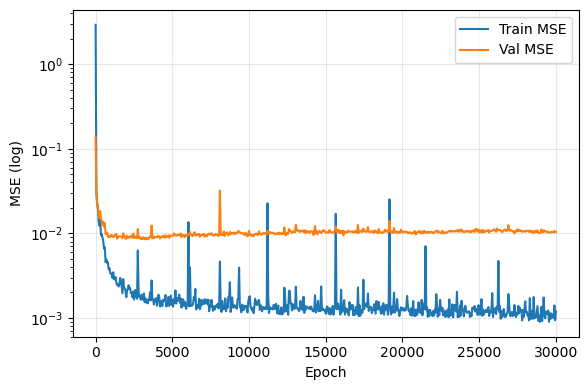

In [ ]:
# ============================================================
# Load dataset -> Train DeepONet -> SAVE model + losses
# ============================================================
from functools import partial
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import jax
import jax.numpy as jnp
import jax.tree_util as tree_util
import numpy as onp
import matplotlib.pyplot as plt

# -----------------------
# Load dataset
# -----------------------
DATA_FILE = "deeponet_nozzle_dataset.npz"
data = onp.load(DATA_FILE, allow_pickle=True)

x      = jnp.array(data["x"], dtype=jnp.float32)
A_true = jnp.array(data["A_true"], dtype=jnp.float32)
M_true = jnp.array(data["M_true"], dtype=jnp.float32)
A_train = jnp.array(data["A_train"], dtype=jnp.float32)
M_train = jnp.array(data["M_train"], dtype=jnp.float32)
A_val   = jnp.array(data["A_val"], dtype=jnp.float32)
M_val   = jnp.array(data["M_val"], dtype=jnp.float32)

N_train = int(A_train.shape[0])
N_val   = int(A_val.shape[0])
N       = int(x.shape[0])

print("Loaded dataset shapes:")
print("Train A:", A_train.shape, "Train M:", M_train.shape)
print("Val   A:", A_val.shape,   "Val   M:", M_val.shape)

# ---------------------------------------------------------------
# Normalization for DeepONet inputs 
# ---------------------------------------------------------------
A_all = jnp.concatenate([A_train, A_val, A_true[None, :]], axis=0)
mu_A  = jnp.mean(A_all)
std_A = jnp.std(A_all) + 1e-6

x_min = float(x[0])
x_max = float(x[-1])
def normalize_x(x_grid):
    return 2.0 * ((x_grid - x_min) / (x_max - x_min) - 0.5)

# ---------------------------------------------------------------
# DeepONet architecture (branch + trunk)
# ---------------------------------------------------------------
def init_layer(key, in_dim, out_dim):
    w_key, _ = jax.random.split(key)
    W = jax.random.normal(w_key, (in_dim, out_dim)) * jnp.sqrt(2.0 / in_dim)
    b = jnp.zeros((out_dim,))
    return (W, b)

def init_mlp(sizes, key):
    params = []
    keys = jax.random.split(key, len(sizes)-1)
    for (m, n), k in zip(zip(sizes[:-1], sizes[1:]), keys):
        params.append(init_layer(k, m, n))
    return params

def mlp_apply(params, x):
    for (W, b) in params[:-1]:
        x = jnp.tanh(x @ W + b)
    W_last, b_last = params[-1]
    return x @ W_last + b_last

def init_deeponet(key, n_grid, p=64,
                  hidden_branch=(128, 128),
                  hidden_trunk=(64, 64)):
    kb, kt, kbias = jax.random.split(key, 3)
    branch_sizes = (n_grid,) + hidden_branch + (p,)
    trunk_sizes  = (1,)      + hidden_trunk  + (p,)

    branch_params = init_mlp(branch_sizes, kb)
    trunk_params  = init_mlp(trunk_sizes,  kt)
    bias = jnp.array(0.0)
    return {"branch": branch_params, "trunk": trunk_params, "bias": bias}

def deeponet_apply_single(params, A_sample, x_grid):
    # Normalize inputs
    A_n = (A_sample - mu_A) / std_A
    x_n = normalize_x(x_grid)[:, None]  # (N,1)

    # branch
    b_feat = mlp_apply(params["branch"], A_n[None, :])[0]  # (p,)
    # trunk
    t_feat = mlp_apply(params["trunk"], x_n)               # (N,p)
    # output in physical Mach units
    M_pred = jnp.sum(t_feat * b_feat[None, :], axis=1) + params["bias"]
    return M_pred

deeponet_apply_single_jit = jax.jit(deeponet_apply_single)

def deeponet_apply_batch(params, A_batch, x_grid):
    return jax.vmap(lambda A: deeponet_apply_single_jit(params, A, x_grid))(A_batch)

# ---------------------------------------------------------------
# Simple Adam optimizer (pure JAX)
# ---------------------------------------------------------------
def tree_zeros_like(tree):
    return tree_util.tree_map(jnp.zeros_like, tree)

def adam_init(params):
    m = tree_zeros_like(params)
    v = tree_zeros_like(params)
    t = jnp.array(0, dtype=jnp.int32)
    return {"m": m, "v": v, "t": t}

def adam_update(params, grads, opt_state, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    t = opt_state["t"] + 1
    m = tree_util.tree_map(lambda m, g: b1 * m + (1 - b1) * g, opt_state["m"], grads)
    v = tree_util.tree_map(lambda v, g: b2 * v + (1 - b2) * (g * g), opt_state["v"], grads)

    m_hat = tree_util.tree_map(lambda m: m / (1 - b1**t), m)
    v_hat = tree_util.tree_map(lambda v: v / (1 - b2**t), v)

    params_new = tree_util.tree_map(
        lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
        params, m_hat, v_hat
    )
    new_state = {"m": m, "v": v, "t": t}
    return params_new, new_state

# ---------------------------------------------------------------
# Train DeepONet (MSE in Mach) 
# ---------------------------------------------------------------
key_global = jax.random.PRNGKey(0)
key_global, key_dn = jax.random.split(key_global)
params_dn = init_deeponet(key_dn, n_grid=N, p=64)
opt_state = adam_init(params_dn)

def mse_loss(params, A_batch, M_true_batch, x_grid):
    M_pred = deeponet_apply_batch(params, A_batch, x_grid)
    return jnp.mean((M_pred - M_true_batch)**2)

@jax.jit
def train_step(params, opt_state, A_batch, M_batch, x_grid):
    def loss_fn(p):
        return mse_loss(p, A_batch, M_batch, x_grid)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    params_new, opt_state_new = adam_update(params, grads, opt_state, lr=1e-3)
    return params_new, opt_state_new, loss

A_train_j = A_train
M_train_j = M_train
A_val_j   = A_val
M_val_j   = M_val

n_epochs   = 30000
batch_size = 20
n_batches  = N_train // batch_size

# store loss history 
train_loss_hist = []
val_loss_hist   = []
epoch_hist      = []
best_val = onp.inf

for epoch in range(n_epochs):
    perm = onp.random.permutation(N_train)
    A_train_j = A_train_j[perm]
    M_train_j = M_train_j[perm]

    epoch_loss = 0.0
    for i in range(n_batches):
        A_batch = A_train_j[i*batch_size:(i+1)*batch_size]
        M_batch = M_train_j[i*batch_size:(i+1)*batch_size]
        params_dn, opt_state, loss_val = train_step(params_dn, opt_state, A_batch, M_batch, x)
        epoch_loss += float(loss_val)
    epoch_loss /= n_batches

    if (epoch+1) % 50 == 0 or epoch == 0:
        M_val_pred = deeponet_apply_batch(params_dn, A_val_j, x)
        val_loss   = float(jnp.mean((M_val_pred - M_val_j)**2))
        print(f"[Epoch {epoch+1:03d}] train_loss={epoch_loss:.4e}, val_loss={val_loss:.4e}")

        train_loss_hist.append(epoch_loss)
        val_loss_hist.append(val_loss)
        epoch_hist.append(epoch+1)

        # save best model checkpoint
        if val_loss < best_val:
            best_val = val_loss

            flat_params, treedef = tree_util.tree_flatten(params_dn)
            flat_params_np = [onp.array(p) for p in flat_params]
            onp.savez("deeponet_params_best.npz", *flat_params_np)

            # save normalization and arch metadata needed to reload
            onp.savez(
                "deeponet_training_meta.npz",
                mu_A=onp.array(mu_A),
                std_A=onp.array(std_A),
                x_min=onp.array(x_min),
                x_max=onp.array(x_max),
                N=onp.array(N),
                p=onp.array(64),
            )

# Save loss history
onp.savez(
    "deeponet_loss_history.npz",
    epoch=onp.array(epoch_hist),
    train=onp.array(train_loss_hist),
    val=onp.array(val_loss_hist),
    best_val=onp.array(best_val),
)
print("Saved: deeponet_params_best.npz, deeponet_training_meta.npz, deeponet_loss_history.npz")

# plot loss
plt.figure(figsize=(6,4))
plt.semilogy(epoch_hist, train_loss_hist, label="Train MSE")
plt.semilogy(epoch_hist, val_loss_hist, label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE (log)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Loaded model checkpoint: deeponet_params_best.npz
Validation MSE: 0.00849704910069704


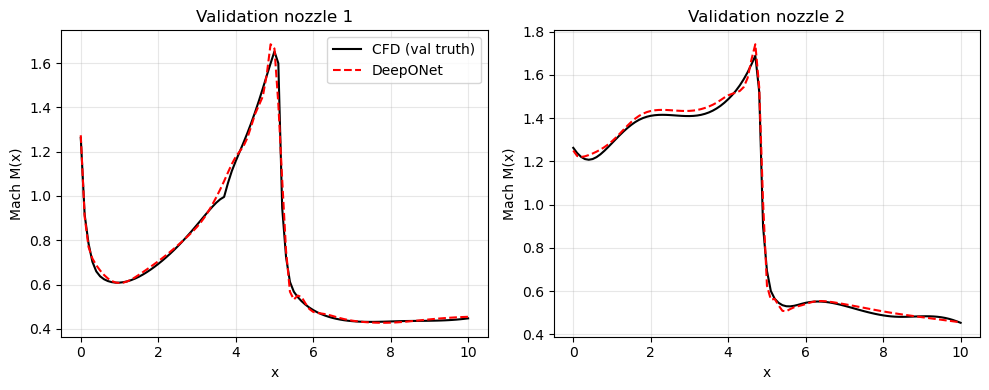

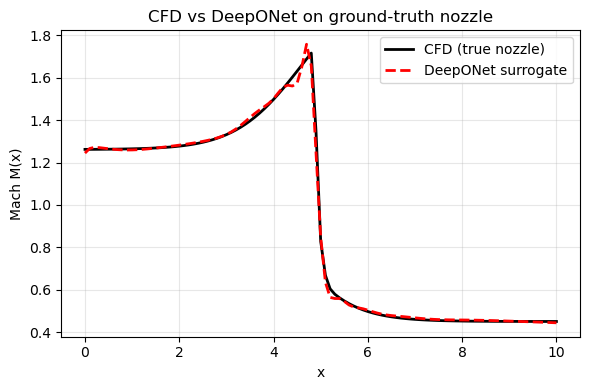

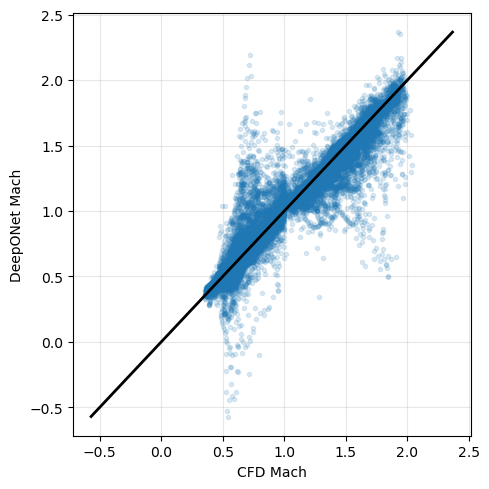

In [ ]:
# ============================================================
# Load model -> Evaluate / validate (plots)
# ============================================================
import os
import jax
import jax.numpy as jnp
import jax.tree_util as tree_util
import numpy as onp
import matplotlib.pyplot as plt

# -----------------------
# Load dataset
# -----------------------
DATA_FILE = "deeponet_nozzle_dataset.npz"
data = onp.load(DATA_FILE, allow_pickle=True)

x      = jnp.array(data["x"], dtype=jnp.float32)
A_true = jnp.array(data["A_true"], dtype=jnp.float32)
M_true = jnp.array(data["M_true"], dtype=jnp.float32)
A_val  = jnp.array(data["A_val"], dtype=jnp.float32)
M_val  = jnp.array(data["M_val"], dtype=jnp.float32)
N = int(x.shape[0])

# -----------------------
# Load training meta
# -----------------------
meta = onp.load("deeponet_training_meta.npz", allow_pickle=True)
mu_A  = jnp.array(meta["mu_A"])
std_A = jnp.array(meta["std_A"])
x_min = float(meta["x_min"])
x_max = float(meta["x_max"])

def normalize_x(x_grid):
    return 2.0 * ((x_grid - x_min) / (x_max - x_min) - 0.5)

# -----------------------
# Rebuild DeepONet 
# -----------------------
def init_layer(key, in_dim, out_dim):
    w_key, _ = jax.random.split(key)
    W = jax.random.normal(w_key, (in_dim, out_dim)) * jnp.sqrt(2.0 / in_dim)
    b = jnp.zeros((out_dim,))
    return (W, b)

def init_mlp(sizes, key):
    params = []
    keys = jax.random.split(key, len(sizes)-1)
    for (m, n), k in zip(zip(sizes[:-1], sizes[1:]), keys):
        params.append(init_layer(k, m, n))
    return params

def mlp_apply(params, x):
    for (W, b) in params[:-1]:
        x = jnp.tanh(x @ W + b)
    W_last, b_last = params[-1]
    return x @ W_last + b_last

def init_deeponet(key, n_grid, p=64,
                  hidden_branch=(128, 128),
                  hidden_trunk=(64, 64)):
    kb, kt, kbias = jax.random.split(key, 3)
    branch_sizes = (n_grid,) + hidden_branch + (p,)
    trunk_sizes  = (1,)      + hidden_trunk  + (p,)

    branch_params = init_mlp(branch_sizes, kb)
    trunk_params  = init_mlp(trunk_sizes,  kt)
    bias = jnp.array(0.0)
    return {"branch": branch_params, "trunk": trunk_params, "bias": bias}

def deeponet_apply_single(params, A_sample, x_grid):
    A_n = (A_sample - mu_A) / std_A
    x_n = normalize_x(x_grid)[:, None]
    b_feat = mlp_apply(params["branch"], A_n[None, :])[0]
    t_feat = mlp_apply(params["trunk"], x_n)
    M_pred = jnp.sum(t_feat * b_feat[None, :], axis=1) + params["bias"]
    return M_pred

deeponet_apply_single_jit = jax.jit(deeponet_apply_single)

def deeponet_apply_batch(params, A_batch, x_grid):
    return jax.vmap(lambda A: deeponet_apply_single_jit(params, A, x_grid))(A_batch)

# -----------------------
# Load saved params (best)
# -----------------------
# Make template treedef
key_tmp = jax.random.PRNGKey(0)
params_template = init_deeponet(key_tmp, n_grid=N, p=64)
flat_template, treedef = tree_util.tree_flatten(params_template)

loaded = onp.load("deeponet_params_best.npz")
flat_loaded = [jnp.array(loaded[f"arr_{i}"]) for i in range(len(loaded.files))]
params_dn = tree_util.tree_unflatten(treedef, flat_loaded)

print("Loaded model checkpoint: deeponet_params_best.npz")

# -----------------------
# Validation loss
# -----------------------
M_val_pred = deeponet_apply_batch(params_dn, A_val, x)
val_mse = float(jnp.mean((M_val_pred - M_val)**2))
print("Validation MSE:", val_mse)

# -----------------------
# random validation cases
# -----------------------
N_test = 2
idx = onp.random.choice(A_val.shape[0], size=N_test, replace=False)

fig, axs = plt.subplots(1, N_test, figsize=(5*N_test, 4))
axs = onp.atleast_1d(axs)
for i in range(N_test):
    j = idx[i]
    axs[i].plot(onp.array(x), onp.array(M_val[j]), 'k-', label='CFD (val truth)')
    axs[i].plot(onp.array(x), onp.array(M_val_pred[j]),  'r--', label='DeepONet')
    axs[i].set_title(f'Validation nozzle {i+1}')
    axs[i].set_xlabel('x'); axs[i].set_ylabel('Mach M(x)')
    axs[i].grid(alpha=0.3)
    if i == 0:
        axs[i].legend()
plt.tight_layout()
plt.show()

# -----------------------
# Plot: ground-truth nozzle comparison
# -----------------------
M_true_dn = deeponet_apply_single_jit(params_dn, A_true, x)

plt.figure(figsize=(6,4))
plt.plot(onp.array(x), onp.array(M_true), 'k-', lw=2, label='CFD (true nozzle)')
plt.plot(onp.array(x), onp.array(M_true_dn), 'r--', lw=2, label='DeepONet surrogate')
plt.xlabel('x'); plt.ylabel('Mach M(x)')
plt.title('CFD vs DeepONet on ground-truth nozzle')
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# Plot: parity plot (all validation points)
# -----------------------
yt = onp.asarray(M_val).ravel()
yp = onp.asarray(M_val_pred).ravel()
mask = onp.isfinite(yt) & onp.isfinite(yp)
yt = yt[mask]; yp = yp[mask]

plt.figure(figsize=(5,5))
plt.plot(yt, yp, ".", alpha=0.15)
mn = min(yt.min(), yp.min())
mx = max(yt.max(), yp.max())
plt.plot([mn, mx], [mn, mx], "k-", lw=2)
plt.xlabel("CFD Mach"); plt.ylabel("DeepONet Mach")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Saved: AppendixC_Figures/FigC_Composite_3x2.png and AppendixC_Figures/FigC_Composite_3x2.pdf


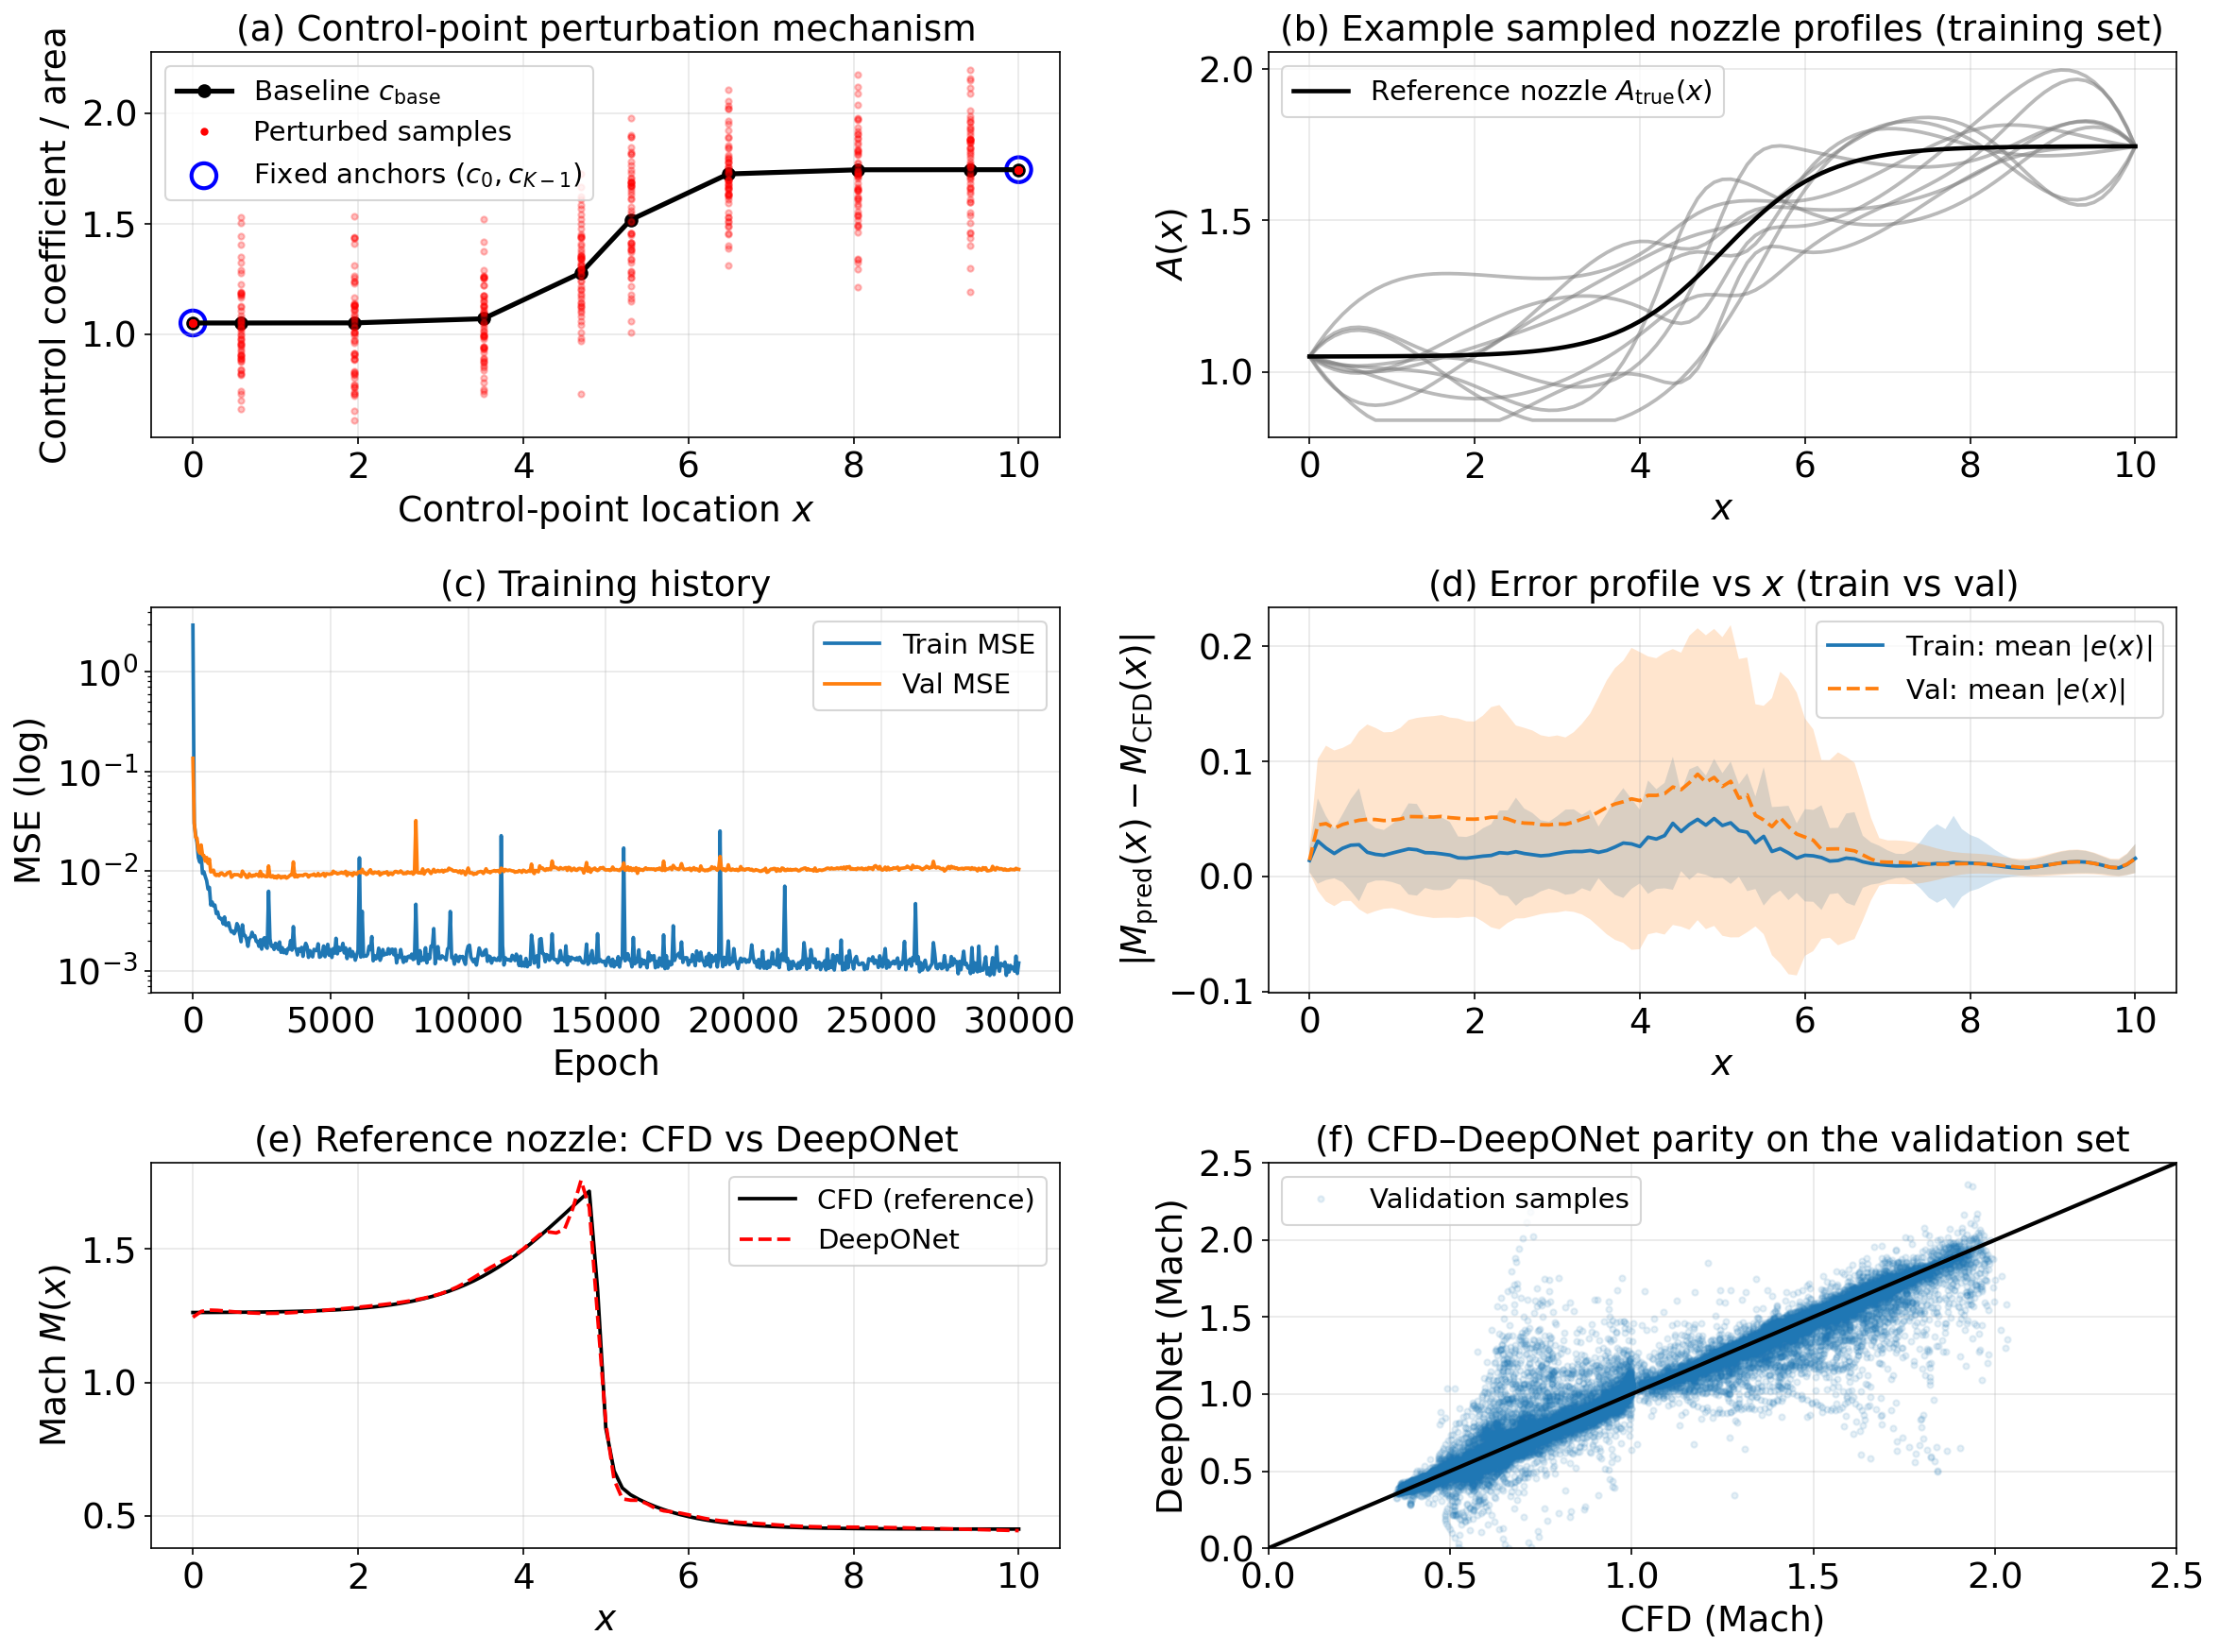

Composite figure saved in: AppendixC_Figures


In [ ]:
# ============================================================
# Composite Figure (3 rows x 2 panels)
#   Row 1: Data generation visuals
#     (a) Control-point perturbation mechanism
#     (b) Resulting nozzle profiles (examples)
#   Row 2: Training behavior
#     (c) Train/Val loss curve
#     (d) Error profile vs x (train vs val mean±std)
#   Row 3: Validation checks
#     (e) Reference nozzle: CFD vs DeepONet
#     (f) Parity plot on validation (axes 0..2.5)
#
# Requires files produced by your pipeline:
#   deeponet_nozzle_dataset.npz
#   deeponet_params_best.npz
#   deeponet_training_meta.npz
#   deeponet_loss_history.npz
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.tree_util as tree_util

# -----------------------------
# Files
# -----------------------------
DATA_FILE   = "deeponet_nozzle_dataset.npz"
PARAM_FILE  = "deeponet_params_best.npz"
META_FILE   = "deeponet_training_meta.npz"
LOSS_FILE   = "deeponet_loss_history.npz"

OUTDIR = "AppendixC_Figures"
os.makedirs(OUTDIR, exist_ok=True)

# -----------------------------
# Global plotting style 
# -----------------------------
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "lines.linewidth": 1.8,
    "figure.dpi": 150
})

def savefig(name):
    png = os.path.join(OUTDIR, f"{name}.png")
    pdf = os.path.join(OUTDIR, f"{name}.pdf")
    plt.tight_layout()
    plt.savefig(png, dpi=300, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print("Saved:", png, "and", pdf)

# -----------------------------
# Load dataset
# -----------------------------
data = np.load(DATA_FILE, allow_pickle=True)
x       = jnp.array(data["x"], dtype=jnp.float32)
A_true  = jnp.array(data["A_true"], dtype=jnp.float32)
M_true  = jnp.array(data["M_true"], dtype=jnp.float32)
A_train = jnp.array(data["A_train"], dtype=jnp.float32)
M_train = jnp.array(data["M_train"], dtype=jnp.float32)
A_val   = jnp.array(data["A_val"], dtype=jnp.float32)
M_val   = jnp.array(data["M_val"], dtype=jnp.float32)

N = int(x.shape[0])

# meta saved as: [N_train, N_val, K_bs, deg_bs, x_c, cluster_width, prior_span]
meta_vec = np.array(data["meta"], dtype=np.float32).ravel()
K_bs         = int(meta_vec[2])
deg_bs       = int(meta_vec[3])
x_c          = float(meta_vec[4])
cluster_w    = float(meta_vec[5])
prior_span   = float(meta_vec[6])

A0_val = float(A_true[0])
AL_val = float(A_true[-1])

# -----------------------------
# Load training meta (normalization + latent dim)
# -----------------------------
meta = np.load(META_FILE, allow_pickle=True)
mu_A  = jnp.array(meta["mu_A"])
std_A = jnp.array(meta["std_A"])
x_min = float(meta["x_min"])
x_max = float(meta["x_max"])
p_lat = int(meta["p"])

def normalize_x(x_grid):
    return 2.0 * ((x_grid - x_min) / (x_max - x_min) - 0.5)

# -----------------------------
# Rebuild DeepONet structure 
# -----------------------------
def init_layer(key, in_dim, out_dim):
    w_key, _ = jax.random.split(key)
    W = jax.random.normal(w_key, (in_dim, out_dim)) * jnp.sqrt(2.0 / in_dim)
    b = jnp.zeros((out_dim,))
    return (W, b)

def init_mlp(sizes, key):
    params = []
    keys = jax.random.split(key, len(sizes)-1)
    for (m, n), k in zip(zip(sizes[:-1], sizes[1:]), keys):
        params.append(init_layer(k, m, n))
    return params

def mlp_apply(params, x):
    for (W, b) in params[:-1]:
        x = jnp.tanh(x @ W + b)
    W_last, b_last = params[-1]
    return x @ W_last + b_last

def init_deeponet(key, n_grid, p=64, hidden_branch=(128, 128), hidden_trunk=(64, 64)):
    kb, kt, _ = jax.random.split(key, 3)
    branch_sizes = (n_grid,) + hidden_branch + (p,)
    trunk_sizes  = (1,)      + hidden_trunk  + (p,)
    branch_params = init_mlp(branch_sizes, kb)
    trunk_params  = init_mlp(trunk_sizes,  kt)
    bias = jnp.array(0.0)
    return {"branch": branch_params, "trunk": trunk_params, "bias": bias}

def deeponet_apply_single(params, A_sample, x_grid):
    A_n = (A_sample - mu_A) / std_A
    x_n = normalize_x(x_grid)[:, None]      # (N,1)
    b_feat = mlp_apply(params["branch"], A_n[None, :])[0]   # (p,)
    t_feat = mlp_apply(params["trunk"], x_n)                # (N,p)
    return jnp.sum(t_feat * b_feat[None, :], axis=1) + params["bias"]

deeponet_apply_single_jit = jax.jit(deeponet_apply_single)

def deeponet_apply_batch(params, A_batch, x_grid):
    return jax.vmap(lambda A: deeponet_apply_single_jit(params, A, x_grid))(A_batch)

# -----------------------------
# Load saved parameters
# -----------------------------
key_tmp = jax.random.PRNGKey(0)
params_template = init_deeponet(key_tmp, n_grid=N, p=p_lat)
flat_template, treedef = tree_util.tree_flatten(params_template)

loaded = np.load(PARAM_FILE)
flat_loaded = [jnp.array(loaded[f"arr_{i}"]) for i in range(len(loaded.files))]
params_dn = tree_util.tree_unflatten(treedef, flat_loaded)

# -----------------------------
# Load loss history
# -----------------------------
loss = np.load(LOSS_FILE, allow_pickle=True)
epoch = loss["epoch"]
train_hist = loss["train"]
val_hist   = loss["val"]
best_val = float(loss["best_val"])

# -----------------------------
# Compute predictions needed for panels
# -----------------------------
M_val_pred = deeponet_apply_batch(params_dn, A_val, x)
val_mse = float(jnp.mean((M_val_pred - M_val)**2))

M_true_dn = deeponet_apply_single_jit(params_dn, A_true, x)

# -----------------------------
# B-spline visuals (for Row 1)
#   Recreate knot sequence + Greville points for illustration.
# -----------------------------
def clustered_knots_x(K, degree, x0, x1, center, width=1.2):
    # number of interior knots for open clamped B-spline:
    # n_int = K - degree - 1
    n_int = K - degree - 1
    left  = max(x0 + 1e-6, center - width)
    right = min(x1 - 1e-6, center + width)
    n_center = max(2, int(0.7 * n_int))
    n_outer = n_int - n_center

    def seg(a, b, n):
        if n <= 0:
            return jnp.array([], dtype=jnp.float32)
        return jnp.linspace(a, b, n + 2, dtype=jnp.float32)[1:-1]

    center_knots = seg(left, right, n_center)
    left_knots   = seg(x0, left, n_outer // 2)
    right_knots  = seg(right, x1, n_outer - (n_outer // 2))

    interior = jnp.sort(jnp.concatenate([left_knots, center_knots, right_knots], axis=0))
    knots = jnp.concatenate([
        jnp.full((degree+1,), x0), interior, jnp.full((degree+1,), x1)
    ])
    return knots

# Greville abscissae for degree p=3:
# g_i = (tau_{i+1}+tau_{i+2}+tau_{i+3})/3
def greville_points(knots, K, degree):
    gv = []
    for i in range(K):
        gv.append(jnp.mean(knots[i+1:i+1+degree]))
    return jnp.array(gv, dtype=jnp.float32)

x0, x1 = float(x[0]), float(x[-1])
knots = clustered_knots_x(K_bs, deg_bs, x0, x1, center=x_c, width=cluster_w)
grev = greville_points(knots, K_bs, deg_bs)  # (K,)

# baseline control coefficients 
s = 0.5 * (1.0 + jnp.tanh(1.2 * (grev - x_c)))
c_base = A0_val + (AL_val - A0_val) * s


np.random.seed(0)
n_mech = 60
delta = prior_span * np.random.randn(n_mech, K_bs-2).astype(np.float32)
C_mech = np.zeros((n_mech, K_bs), dtype=np.float32)
C_mech[:, 0] = A0_val
C_mech[:, -1] = AL_val
C_mech[:, 1:-1] = np.asarray(c_base[1:-1])[None, :] + delta

# For nozzle-profile examples
n_profiles = 10

# -----------------------------
# Build the 3x2 composite
# -----------------------------
fig, axs = plt.subplots(3, 2, figsize=(16, 12))
(ax11, ax12), (ax21, ax22), (ax31, ax32) = axs

# ===== Row 1 (a): mechanism =====
ax11.plot(np.asarray(grev), np.asarray(c_base), "k-o", lw=2.5, label="Baseline $c_{\\mathrm{base}}$")
ax11.plot(np.asarray(grev)[None, :].repeat(n_mech, axis=0).T, C_mech.T, "r.", alpha=0.25)
ax11.plot([], [], "r.", label="Perturbed samples")
ax11.scatter([float(grev[0]), float(grev[-1])], [A0_val, AL_val],
             s=160, facecolors="none", edgecolors="blue", lw=2.0,
             label="Fixed anchors ($c_0,c_{K-1}$)")
ax11.set_title("(a) Control-point perturbation mechanism")
ax11.set_xlabel("Control-point location $x$")
ax11.set_ylabel("Control coefficient / area")
ax11.grid(alpha=0.3)
ax11.legend(loc="upper left")

# ===== Row 1 (b): nozzle profiles =====
for i in range(n_profiles):
    ax12.plot(np.asarray(x), np.asarray(A_train[i]), color="gray", alpha=0.55)
ax12.plot(np.asarray(x), np.asarray(A_true), "k-", lw=2.2, label="Reference nozzle $A_{\\mathrm{true}}(x)$")
ax12.set_title("(b) Example sampled nozzle profiles (training set)")
ax12.set_xlabel("$x$")
ax12.set_ylabel("$A(x)$")
ax12.grid(alpha=0.3)
ax12.legend(loc="upper left")

# ===== Row 2 (c): loss curve =====
ax21.semilogy(epoch, train_hist, label="Train MSE")
ax21.semilogy(epoch, val_hist,   label="Val MSE")
# ax21.axhline(best_val, linestyle="--", lw=1.2, label=f"Best val = {best_val:.2e}")
ax21.set_title("(c) Training history")
ax21.set_xlabel("Epoch")
ax21.set_ylabel("MSE (log)")
ax21.grid(alpha=0.3)
ax21.legend(loc="upper right")

# ===== Row 2 (d): error profile vs x (train vs val) =====

n_train_err = min(400, int(A_train.shape[0]))
np.random.seed(0)
idx_err = np.random.choice(int(A_train.shape[0]), size=n_train_err, replace=False)

M_train_pred_err = deeponet_apply_batch(params_dn, A_train[idx_err], x)
train_err = np.asarray(jnp.abs(M_train_pred_err - M_train[idx_err]))  # (n_train_err, N)
val_err   = np.asarray(jnp.abs(M_val_pred - M_val))                    # (N_val, N)

train_mean = train_err.mean(axis=0)
train_std  = train_err.std(axis=0)
val_mean   = val_err.mean(axis=0)
val_std    = val_err.std(axis=0)

ax22.plot(np.asarray(x), train_mean, label="Train: mean $|e(x)|$")
ax22.fill_between(np.asarray(x), train_mean-train_std, train_mean+train_std, alpha=0.2)

ax22.plot(np.asarray(x), val_mean, linestyle="--", label="Val: mean $|e(x)|$")
ax22.fill_between(np.asarray(x), val_mean-val_std, val_mean+val_std, alpha=0.2)

ax22.set_title("(d) Error profile vs $x$ (train vs val)")
ax22.set_xlabel("$x$")
ax22.set_ylabel(r"$|M_{\mathrm{pred}}(x)-M_{\mathrm{CFD}}(x)|$")
ax22.grid(alpha=0.3)
ax22.legend(loc="upper right")

# ===== Row 3 (e): reference nozzle CFD vs DeepONet =====
ax31.plot(np.asarray(x), np.asarray(M_true), "k-",  label="CFD (reference)")
ax31.plot(np.asarray(x), np.asarray(M_true_dn), "r--", label="DeepONet")
ax31.set_title("(e) Reference nozzle: CFD vs DeepONet")
ax31.set_xlabel("$x$")
ax31.set_ylabel("Mach $M(x)$")
ax31.grid(alpha=0.3)
ax31.legend(loc="upper right")

# ===== Row 3 (f): parity plot  =====
yt = np.asarray(M_val).ravel()
yp = np.asarray(M_val_pred).ravel()
mask = np.isfinite(yt) & np.isfinite(yp)
yt = yt[mask]; yp = yp[mask]

mn, mx = 0.0, 2.5
ax32.plot(yt, yp, ".", alpha=0.11, label="Validation samples")
ax32.plot([mn, mx], [mn, mx], "k-", lw=2.0)
ax32.set_xlim(mn, mx)
ax32.set_ylim(mn, mx)
ax32.set_title(f"(f) CFD–DeepONet parity on the validation set")
ax32.set_xlabel("CFD (Mach)")
ax32.set_ylabel("DeepONet (Mach)")
ax32.grid(alpha=0.3)
ax32.legend(loc="upper left")

# -----------------------------
# Save
# -----------------------------
savefig("FigC_Composite_3x2")
plt.show()

print("Composite figure saved in:", OUTDIR)


Nobs=5:
  CFD -> inverse_nozzle_bspline_5.npz
  DN  -> inverse_results_DeepONet_5obs.npz
Nobs=10:
  CFD -> inverse_nozzle_bspline_100.npz
  DN  -> inverse_results_DeepONet_10obs.npz
Nobs=20:
  CFD -> inverse_nozzle_bspline_20.npz
  DN  -> inverse_results_DeepONet_20obs.npz
Nobs=40:
  CFD -> inverse_nozzle_bspline_40.npz
  DN  -> inverse_results_DeepONet_40obs.npz
Nobs=80:
  CFD -> inverse_nozzle_bspline_80.npz
  DN  -> inverse_results_DeepONet_80obs.npz
Nobs=100:
  CFD -> inverse_nozzle_bspline_100.npz
  DN  -> inverse_results_DeepONet_100obs.npz


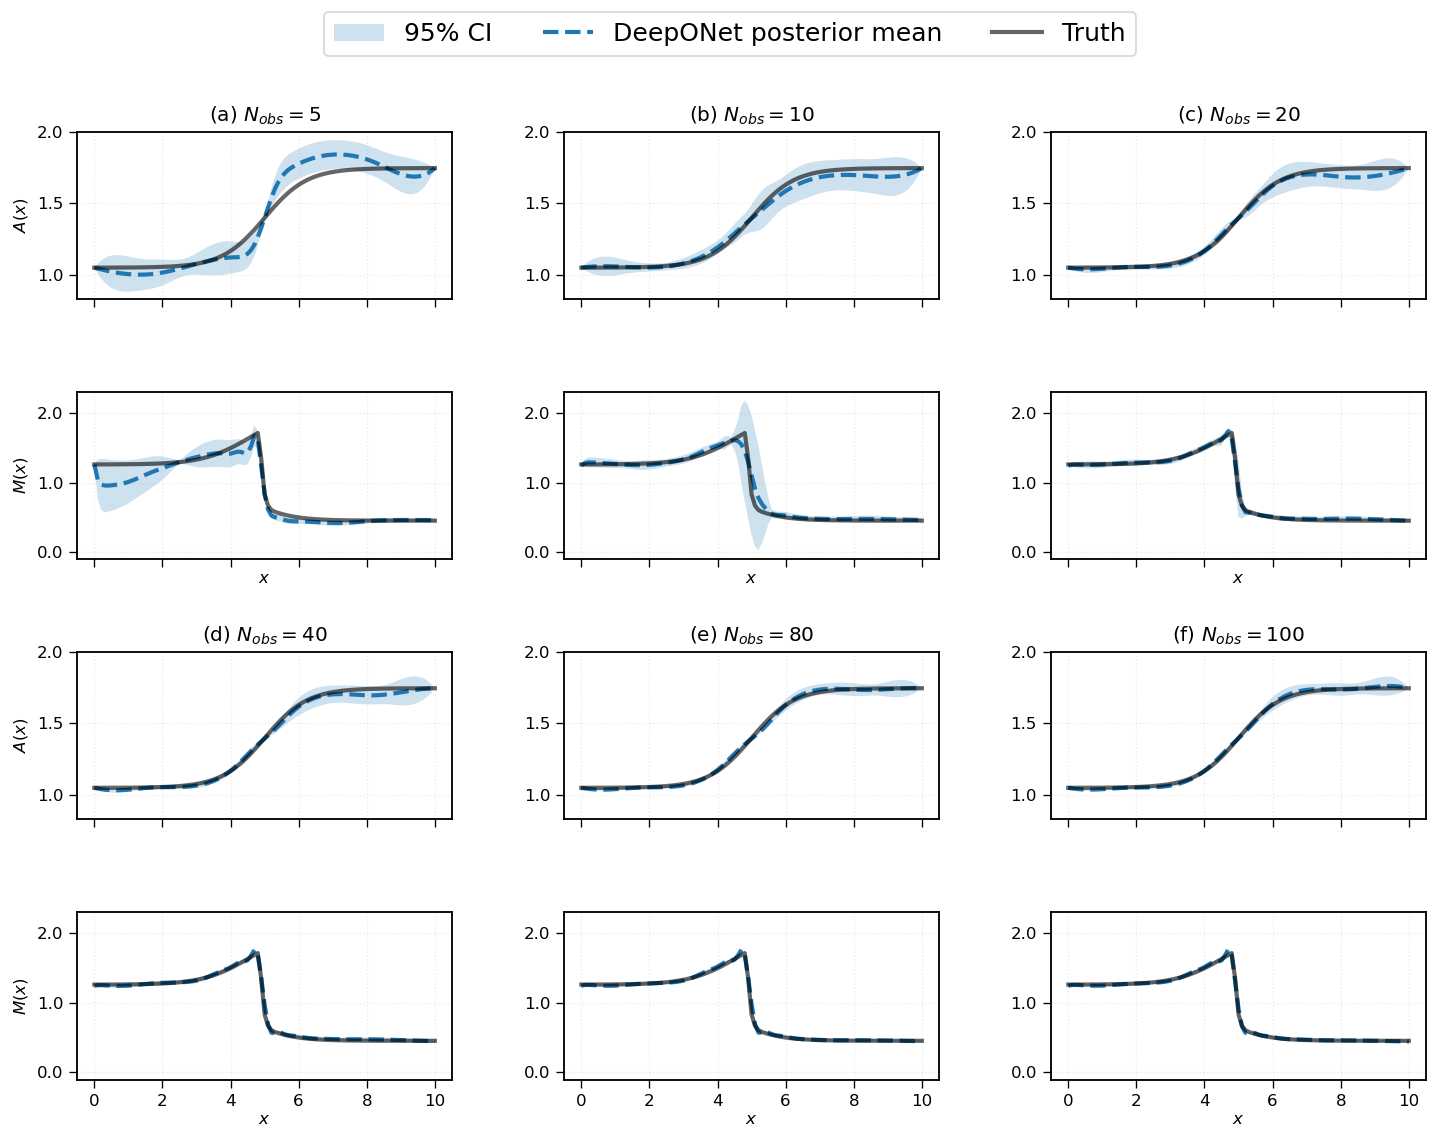

Saved: R5_DeepONet_6cases_top_5_10_20_bottom_40_80_100.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# -----------------------------
# Plot Style
# -----------------------------
plt.rcParams.update({
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "legend.fontsize": 15,
    "figure.dpi": 120,
    "savefig.dpi": 400,

    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.1,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

# -----------------------------
# Helpers
# -----------------------------
def latest(pattern):
    f = sorted(glob.glob(pattern))
    assert f, f"No files matched: {pattern}"
    return f[-1]

def load_npz(path):
    d = np.load(path, allow_pickle=False)
    return {k: d[k] for k in d.files}

def ensure_bands(d, prefix):
    mu = d.get(f"{prefix}_mu")
    lo = d.get(f"{prefix}_lo")
    hi = d.get(f"{prefix}_hi")
    sd = d.get(f"{prefix}_sd")
    if (lo is None) or (hi is None):
        assert (mu is not None) and (sd is not None), f"Missing bands for {prefix}"
        d[f"{prefix}_lo"] = mu - 2.0 * sd
        d[f"{prefix}_hi"] = mu + 2.0 * sd

def plot_band(ax, x, truth, mu, lo, hi, title="", ylabel=""):
    h_ci = ax.fill_between(x, lo, hi, alpha=0.22, label="95% CI", zorder=1)
    h_mu, = ax.plot(x, mu, linestyle="--", lw=2.5, label="DeepONet posterior mean", zorder=3)
    h_tr, = ax.plot(x, truth, "k", lw=2.5, alpha=0.6, label="Truth", zorder=4)

    if title:
        ax.set_title(title, pad=6)
    ax.set_ylabel(ylabel)
    ax.grid(True)

    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)

    return (h_ci, h_mu, h_tr)

def padded_limits(arr_list, pad_frac=0.05):
    a = np.concatenate([np.ravel(np.asarray(v)) for v in arr_list])
    lo, hi = np.min(a), np.max(a)
    pad = pad_frac * (hi - lo + 1e-12)
    return lo - pad, hi + pad

# -----------------------------
# Observation counts
# -----------------------------
NOBS_TOP    = [5, 10, 20]
NOBS_BOTTOM = [40, 80, 100]
NOBS_ALL    = NOBS_TOP + NOBS_BOTTOM

# panel labels for titles
PANEL_TOP = ["(a)", "(b)", "(c)"]
PANEL_BOT = ["(d)", "(e)", "(f)"]

# -----------------------------
# Load all data first
# -----------------------------
DATA = {}
for Nobs in NOBS_ALL:
    # CFD inverse (truth + grid)
    cfd_path = latest(f"inverse_nozzle_bspline_{Nobs}*.npz")
    cfd = load_npz(cfd_path)
    ensure_bands(cfd, "A")
    ensure_bands(cfd, "M")

    # DeepONet inverse (posterior mean + CI)
    dn_path = f"inverse_results_DeepONet_{Nobs}obs.npz"
    dn = load_npz(dn_path)
    ensure_bands(dn, "A")
    ensure_bands(dn, "M")

    DATA[Nobs] = dict(CFD=cfd, DN=dn)

    print(f"Nobs={Nobs}:")
    print("  CFD ->", cfd_path)
    print("  DN  ->", dn_path)

# -----------------------------
# Consistent y-limits
# -----------------------------
A_all, M_all = [], []
for Nobs in NOBS_ALL:
    for key in ["CFD", "DN"]:
        d = DATA[Nobs][key]
        A_all += [d["A_true"], d["A_mu"], d["A_lo"], d["A_hi"]]
        M_all += [d["M_true"], d["M_mu"], d["M_lo"], d["M_hi"]]

A_ylim = padded_limits(A_all, 0.05)
M_ylim = padded_limits(M_all, 0.06)

A_ylim = (min(A_ylim[0], 1.0), max(A_ylim[1], 2.0))
M_ylim = (min(M_ylim[0], 0.0), max(M_ylim[1], 2.0))


A_TICKS = [1.0, 1.5, 2.0]
M_TICKS = [0.0, 1.0, 2.0]
M_TICKLABELS = ["0.0", "1.0", "2.0"]

# -----------------------------
# Figure: 4 × 3
# Rows 0-1 => Nobs = 5,10,20  (A then M)
# Rows 2-3 => Nobs = 40,80,100 (A then M)
# -----------------------------
fig, axes = plt.subplots(
    4, 3,
    figsize=(14.5, 10.0),
    sharex=True,
    gridspec_kw={"wspace": 0.30, "hspace": 0.55}
)

legend_handles = None

def fill_block(col_list, rowA, rowM, panel_tags):
    global legend_handles
    for j, Nobs in enumerate(col_list):
        cfd = DATA[Nobs]["CFD"]
        dn  = DATA[Nobs]["DN"]
        x = cfd["x"]

        title = fr"{panel_tags[j]} $N_{{obs}} = {Nobs}$"

        # --- A(x)
        h = plot_band(
            axes[rowA, j], x,
            truth=cfd["A_true"],
            mu=dn["A_mu"], lo=dn["A_lo"], hi=dn["A_hi"],
            title=title,
            ylabel=r"$A(x)$" if j == 0 else "",
        )
        axes[rowA, j].set_ylim(*A_ylim)
        axes[rowA, j].set_yticks(A_TICKS)

        # --- M(x)
        _ = plot_band(
            axes[rowM, j], x,
            truth=cfd["M_true"],
            mu=dn["M_mu"], lo=dn["M_lo"], hi=dn["M_hi"],
            title="",
            ylabel=r"$M(x)$" if j == 0 else "",
        )
        axes[rowM, j].set_ylim(*M_ylim)
        axes[rowM, j].set_yticks(M_TICKS)
        axes[rowM, j].set_yticklabels(M_TICKLABELS)

        # make x-label smaller (your “small x” request)
        axes[rowM, j].set_xlabel(r"$x$", labelpad=2)

        if legend_handles is None:
            legend_handles = h  # (CI, mean, truth)

# Top block
fill_block(NOBS_TOP, rowA=0, rowM=1, panel_tags=PANEL_TOP)
# Bottom block
fill_block(NOBS_BOTTOM, rowA=2, rowM=3, panel_tags=PANEL_BOT)

# -----------------------------
# Legend placement 
# -----------------------------
fig.legend(
    legend_handles,
    ["95% CI", "DeepONet posterior mean", "Truth"],
    loc="upper center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 1.01)
)

fig.subplots_adjust(top=0.90)

out_png = "R5_DeepONet_6cases_top_5_10_20_bottom_40_80_100.png"
plt.savefig(out_png, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
